<a href="https://colab.research.google.com/github/noorbushra470-alt/hotel-booking-cancellation-prediction/blob/main/hotel_booking_cancellation_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Cancallation Prediction

**Load Data**

Load Hotel_Booking/hotel_bookings.csv file provided on Brightspace.

In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# sklearn modules for later steps
from sklearn.model_selection import train_test_split # Used for Data Splitting
from sklearn.tree import DecisionTreeClassifier # Used for Model Training
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Used for Model Evaluation
from sklearn.preprocessing import StandardScaler, MinMaxScaler # Used for Scaling
from sklearn.preprocessing import LabelEncoder # Used for Encoding


In the above cell, I have imported all the Python libraries required for this Assignment.
Here is the explaination of every libraray where it is used:


*   Numpy: Used for handling arrays, performing mathematical operations during data preprocessing, analysis and for performing fast mathematical operations.
*   Pandas: Used for loading, cleaning, handling missing values, analyzing data and perform Exploratory Data Analysis(EDA).
*   Matplotlib & Seaborn: Used for outliers, data visualization, creating box plots, heatmaps and bar charts.
*   Scikit-learn (sklearn): Used for machine learning tasks, splitting data into training and testing sets, training models and evaluating model accuracy.





In [ ]:
# Load Data
df = pd.read_csv("hotel_bookings.csv")
print("Shape:", df.shape)
df.head()


Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In the above step i have loaded the dataset into Pandas Data Frame using function read_csv cause its easy and most accurate way for reading CSV file in Python, after loading I checked the shape of DataFrame by displaying the shape and then used the head() function to display first few records which gives an overview of the dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

Justifications:

The above line gives the summary of the Dataframe(df).

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Justifications:

The above line gives a statistical summary of numerical columns in Dataframe(df).

# 1. Data Pre-processing (25%)


---






**Drop irrelevant columns**

It will significantly reduce the time and effort you need to invest. As a general guideline, columns containing IDs, dates, or irrelevant information are typically considered redundant and offer little value for predictive analysis.

In [ ]:
df.drop(['company', 'agent', 'reservation_status_date', 'reservation_status'], axis=1, inplace=True)

print("Updated dataset shape:", df.shape)

Updated dataset shape: (119390, 28)


Justifications:

This code removes four columns "company", "agent", "reservation_status_date", and "reservation_status" from the dataset because they aren’t needed for our analysis. Using axis=1 tells pandas to drop columns, and "inplace=True" updates the DataFrame directly without creating a copy.This step helps clean the data and overall, it makes the dataset simpler and easier to work with for further analysis.

## Unique values

Find out unique values in columns. This will help you in identifying in-consistent data.

In [ ]:
print(df['deposit_type'].unique())
print(df[["deposit_type"]].value_counts())

print(df["hotel"].unique())
print(df[["hotel"]].value_counts())

print(df["arrival_date_month"].unique())
print(df[["arrival_date_month"]].value_counts())

print(df["meal"].unique())
print(df[["meal"]].value_counts())

print(df["country"].unique())
print(df[["country"]].value_counts())

print(df["market_segment"].unique())
print(df[["market_segment"]].value_counts())

print(df["distribution_channel"].unique())
print(df[["distribution_channel"]].value_counts())

print(df["reserved_room_type"].unique())
print(df[["reserved_room_type"]].value_counts())

print(df["assigned_room_type"].unique())
print(df[["assigned_room_type"]].value_counts())

print(df["customer_type"].unique())
print(df[["customer_type"]].value_counts())



['No Deposit' 'Refundable' 'Non Refund']
deposit_type
No Deposit      104641
Non Refund       14587
Refundable         162
Name: count, dtype: int64
['Resort Hotel' 'City Hotel']
hotel       
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
arrival_date_month
August                13877
July                  12661
May                   11791
October               11160
April                 11089
June                  10939
September             10508
March                  9794
February               8068
November               6794
December               6780
January                5929
Name: count, dtype: int64
['BB' 'FB' 'HB' 'SC' 'Undefined']
meal     
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' '

Justifications:

This code is checking the "unique values" and their counts for several important columns in the dataset. It helps us understand what kind of data each column holds, like different hotel types, room types, meal plans, countries, or customer types. By looking at the counts, we can see which categories are most common and which are rare, which is useful for analysis or cleaning. This step makes the dataset more understandable and helps us decide if any values need fixing, grouping, or special attention. Overall, it’s a way to get a clear snapshot of the dataset’s categorical information.


## 1.1 Missing Values (10%)

Identify and handle missing values.

In [ ]:
# Missing values
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


Justifications:

This line checks for missing or null values in the dataset. df.isnull()"shows which are missing values, and .sum() counts how many are missing in each column. It helps us quickly see which columns have incomplete data that might need cleaning, filling, or removing. This step is important to ensure our analysis or model isn’t affected by missing information.


In [ ]:
# Handling Missing Values

#  Replace numeric missing values with mean
df['children'].fillna(df['children'].mean(), inplace=True)

#  Replace categorical missing values with mode
df['country'].fillna(df['country'].mode()[0], inplace=True)


/tmp/ipython-input-2589944893.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(df['children'].mean(), inplace=True)
/tmp/ipython-input-2589944893.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

Justifications:

In the above line I replaced missing values in the "children" column with the mean because it’s a numeric column. Using the mean gives a reasonable average.For the "country" column, cause it is categorical, we used the mode  because it’s the most common entry and keeps the category meaningful. This approach fills missing data in a simple and easy way, so the dataset is complete and ready for analysis.


## 1.2 Removing Inconsistent values and Outliers (10%)

Detecting inconsistencies can be achieved through a variety of methods. Some can be identified by examining unique values within each column, while others may require a solid understanding of the problem domain. Since you might not be an expert in the hotel or hospitality industry, here are some helpful hints:

Hints:

1. Check for incomplete bookings, such as reservations with zero adults, babies, or children.
2. Examine rows with zeros in both 'stays_in_weekend_nights' and 'stays_in_week_nights.'



In [ ]:
# Checking for incomplete bookings where adults, children, and babies are all zero
incomplete_bookings = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print("Incomplete Bookings:", incomplete_bookings.shape[0])

# Dropping those rows
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]

# Checking for rows where both stay durations are zero
zero_stay = df[(df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)]
print("Zero stay bookings:", zero_stay.shape[0])

# Dropping those rows too
df = df[~((df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0))]

print("Data shape after removing inconsistent values:", df.shape)



Incomplete Bookings: 180
Zero stay bookings: 645
Data shape after removing inconsistent values: (118565, 28)


Justifications:

In the above cell I cleaned the data by removing the bookings that are not right. In the first line I got rid of rows where children, adults and babies are all zero, because a booking with no guest is impossible. In the remaining lines it reomves the rows where both weekend and week-night stays are zero, means that guests didnt stayed in. This makes the data more accurate and less noisy and this is an important step in making the data capable of testing and training.

## 1.3 Column data type conversion (5%)

All necessary columns should be correctly converted to appropriate data types.


In [ ]:
# Checking the current data types
df.info()

# Example conversions

# Convert numerical columns stored as strings into numeric type
df['children'] = pd.to_numeric(df['children'], errors='coerce')

# Map month names to numbers
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

# Convert 'arrival_date_month' to numeric
df['arrival_date_month'] = df['arrival_date_month'].map(month_map)

# Confirm the change
print(df['arrival_date_month'].head())
print(df['arrival_date_month'].dtype)

# Confirming conversions
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 118565 entries, 2 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118565 non-null  object 
 1   is_canceled                     118565 non-null  int64  
 2   lead_time                       118565 non-null  int64  
 3   arrival_date_year               118565 non-null  int64  
 4   arrival_date_month              118565 non-null  object 
 5   arrival_date_week_number        118565 non-null  int64  
 6   arrival_date_day_of_month       118565 non-null  int64  
 7   stays_in_weekend_nights         118565 non-null  int64  
 8   stays_in_week_nights            118565 non-null  int64  
 9   adults                          118565 non-null  int64  
 10  children                        118565 non-null  float64
 11  babies                          118565 non-null  int64  
 12  meal                 

Justifications:

The above cell converts each column into right datat type so the dataset can be analyzed correctly.For example, "arrival_date_month" column, which had month names as strings, was mapped to numbers(January = 1, February = 2).

# 2. Exploratory Data Analysis (25%)


---





You've also been provided with examples of valuable insights that could be of interest to hotel management, including:

* Calculating cancellation percentages for City and Resort hotels.
* Identifying the most frequently ordered meal types.
* Determining the number of returning guests.
* Discovering the most booked room types.
* Exploring correlations between room types and cancellations.


For each of these tasks, choose a suitable type of visualisation covered in
the practical sessions, such as:

* Bar graphs
* Pie charts
* Line charts
* Heatmaps

## 2.1. Calculating cancellation percentages for City and Resort hotels.

/tmp/ipython-input-3230440016.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancellation_rate.index, y=cancellation_rate.values, palette='Blues')


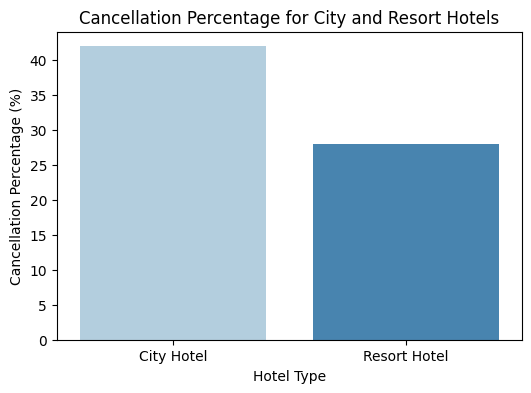

In [ ]:
# Calculate cancellation percentage for each hotel type
cancellation_rate = df.groupby('hotel')['is_canceled'].mean() * 100

# Visualize using a bar chart
plt.figure(figsize=(6,4))
sns.barplot(x=cancellation_rate.index, y=cancellation_rate.values, palette='Blues')
plt.title("Cancellation Percentage for City and Resort Hotels")
plt.ylabel("Cancellation Percentage (%)")
plt.xlabel("Hotel Type")
plt.show()


Justifications:

In the above cell,I have split the dataset into 2 groups of "hotel" for City Hotel and Resort Hotel to calculate the mean "is_cancelled". Multiplying by 100 converts it to a percentage. The bar chart visually compares cancellation rates for both hotel types. The bar Chart shows that City Hotel has more cancellations as its bar is high.

## 2.2. Identifying the most frequently ordered meal types.

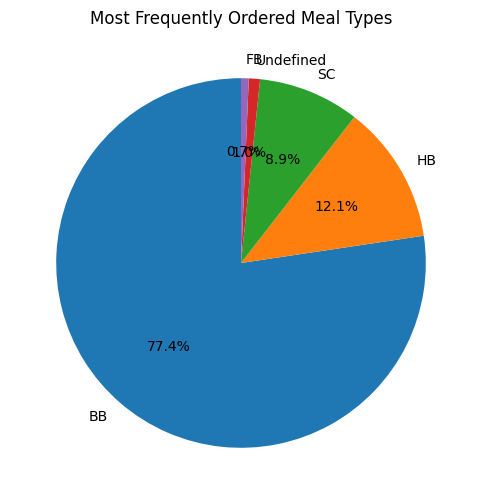

In [ ]:
# Count meal types
meal_counts = df['meal'].value_counts()

# Visualize with a pie chart
plt.figure(figsize=(6,6))
plt.pie(meal_counts, labels=meal_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Most Frequently Ordered Meal Types")
plt.show()


Justifications:

In the above cell, the code counts how many times each meal(HB,BB,FB,SC) was ordered.A pie chart is ideal for showing parts of a whole in this case, which meal types make up the largest share of total bookings. It visually shows the popularity of different meal plans.

## 2.3. Determining the number of returning guests.

/tmp/ipython-input-3622050220.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=returning_guests.index, y=returning_guests.values, palette='Greens')


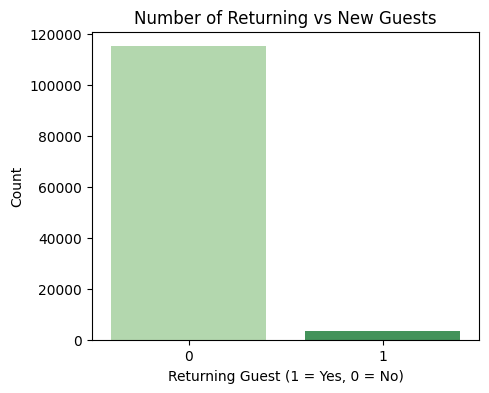

In [ ]:
# Check total and returning guests
returning_guests = df['is_repeated_guest'].value_counts()

# Bar plot
plt.figure(figsize=(5,4))
sns.barplot(x=returning_guests.index, y=returning_guests.values, palette='Greens')
plt.title("Number of Returning vs New Guests")
plt.xlabel("Returning Guest (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()


Justifications:

In the above cell I checked the number of guests returning using "is_repeated_guest" column, new(0) and returning(1).A bar chart is suitable for categorical data comparison it clearly shows how many bookings came from new customers and how many came from repeated customers.

## 2.4. Discovering the most booked room types.

/tmp/ipython-input-762532971.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=room_counts.index, y=room_counts.values, palette='Purples')


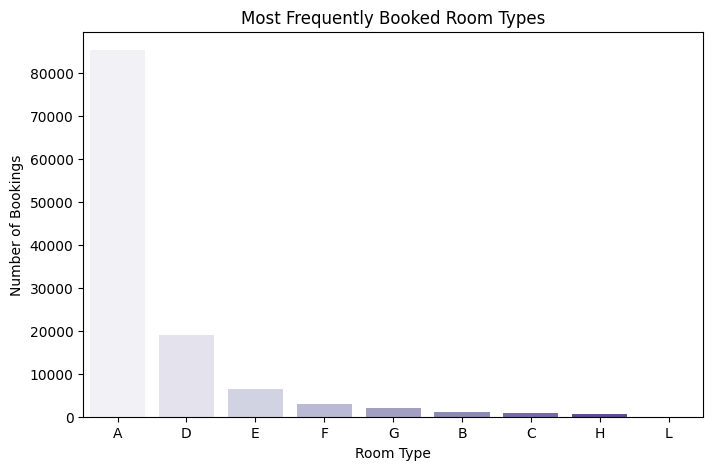

In [ ]:
# Find most booked room types
room_counts = df['reserved_room_type'].value_counts()

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=room_counts.index, y=room_counts.values, palette='Purples')
plt.title("Most Frequently Booked Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Bookings")
plt.show()


Justifications:

In the above cell, the code counts how often each room was booked, then top few rooms are shown in bar chart. Bar chart works best here cause we can compare one room with other room to know the difference between both of their popularity among cutomers.

## 2.5. Exploring correlations between room types and cancellations.

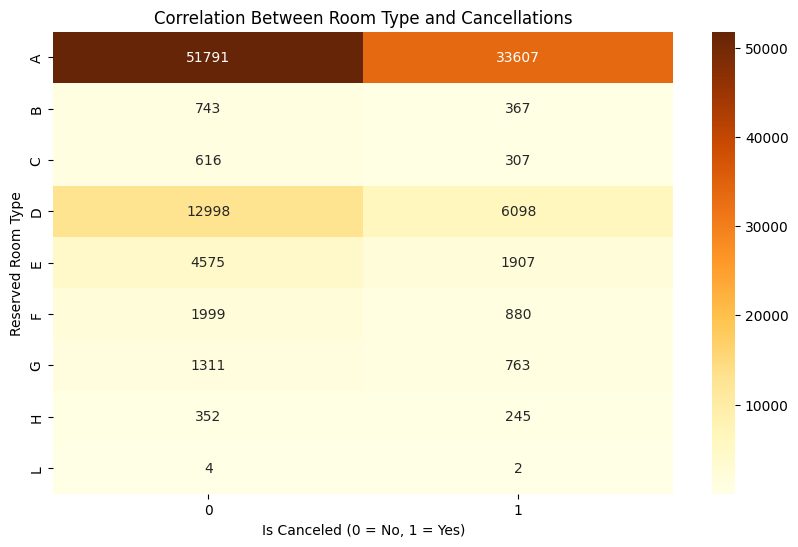

In [ ]:
# Create a cross-tabulation
room_cancel_corr = pd.crosstab(df['reserved_room_type'], df['is_canceled'])

# Heatmap visualization
plt.figure(figsize=(10,6))
sns.heatmap(room_cancel_corr, annot=True, fmt='d', cmap='YlOrBr')
plt.title("Correlation Between Room Type and Cancellations")
plt.xlabel("Is Canceled (0 = No, 1 = Yes)")
plt.ylabel("Reserved Room Type")
plt.show()


Justifications:

In th above cell, the code creates a table that shows a comparison of room types with cancellation statuts.A heatmap is ideal for showing relationships between two categorical variables color intensity quickly indicates where cancellations are most common.

# 3. Feature Engineering (20%)


---





Apply various feature engineering techniques, covered in the lectures and practicals.

Hint:
* Binning
* Encoding
* Scaling
* Feature selection

In [ ]:
# Binning

# Creating bins for lead_time
df['lead_time_bin'] = pd.cut(df['lead_time'],
                             bins=[0, 30, 90, 180, 365, 700],
                             labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])


Justifications:

Binning:
I grouped the "lead_time"  values into categories like "Very Short" to "Very Long" to make it easier to see how booking duration affects cancellations. This also helps reduce the impact of extreme values and random noise. Overall, it makes the data simpler, clearer, and easier to analyze or use in a model.



In [ ]:
# Encoding
# Label Encoding
LE_hotel = LabelEncoder()
df['hotel'] = LE_hotel.fit_transform(df['hotel'])
print("Hotel classes:", LE_hotel.classes_)

LE_deposit = LabelEncoder()
df['deposit_type'] = LE_deposit.fit_transform(df['deposit_type'])
print("Deposit classes:", LE_deposit.classes_)

LE_customer = LabelEncoder()
df['customer_type'] = LE_customer.fit_transform(df['customer_type'])
print("Customer type classes:", LE_customer.classes_)


print("Label Encoding applied Succefully.")

# Print all column names clearly
for col in df.columns:
    print(col)

# Remove any spaces in column names
df.columns = df.columns.str.strip()

# List of columns to encode
cols_to_encode = ['meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'arrival_date_month']

# Keep only columns that actually exist in the dataframe
cols_to_encode = [col for col in cols_to_encode if col in df.columns]

# Now apply One-Hot Encoding
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

print("One-Hot Encoding applied Successfully")

# Encoding remaining object columns before train-test split
from sklearn.preprocessing import LabelEncoder

LE_country = LabelEncoder()
df['country'] = LE_country.fit_transform(df['country'].astype(str))

LE_room = LabelEncoder()
df['assigned_room_type'] = LE_room.fit_transform(df['assigned_room_type'].astype(str))

print("Extra label encoding applied successfully!")
print("Remaining object columns:", df.select_dtypes(include=['object']).columns.tolist())


Hotel classes: ['City Hotel' 'Resort Hotel']
Deposit classes: ['No Deposit' 'Non Refund' 'Refundable']
Customer type classes: ['Contract' 'Group' 'Transient' 'Transient-Party']
Label Encoding applied Succefully.
hotel
is_canceled
lead_time
arrival_date_year
arrival_date_month
arrival_date_week_number
arrival_date_day_of_month
stays_in_weekend_nights
stays_in_week_nights
adults
children
babies
meal
country
market_segment
distribution_channel
is_repeated_guest
previous_cancellations
previous_bookings_not_canceled
reserved_room_type
assigned_room_type
booking_changes
deposit_type
days_in_waiting_list
customer_type
adr
required_car_parking_spaces
total_of_special_requests
lead_time_bin
One-Hot Encoding applied Successfully
Extra label encoding applied successfully!
Remaining object columns: []


Justifications:

Encoding:


*   Label Encoding:

I used Label Encoding for columns like "deposit_type", "customer_type", "assigned_room_type","country" as these columns have categorical values without order, and machine learning ,models need numbers instead of text. Label Encoding converts each category into unique number, making it useful for models.
*   One-Hot Encoding:

I used One-Hot Encoding for columns like "market_segment", "distribuition_channel", "arrival_date_month", "meal" and "reserved_room_type" as this creates separate binary columns for each category, that prevents model from assuming any orser or priority between categories.



In [ ]:
# Convert any categorical columns to numeric codes
for col in df.select_dtypes(include=['category']).columns:
    df[col] = df[col].cat.codes
    print(f"Converted '{col}' from category to numeric codes.")


Converted 'lead_time_bin' from category to numeric codes.


In this cell we are converting any remaining categorical column in the dataset into numeric codes.For example, "lead_time_bin" was a category like "Very Short", "Short" and now each category is replaced with a number. This is important because machine learning models can only work with numbers, not text or category labels.

In [ ]:
# Scaling

# Min-Max Scaling
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[['lead_time', 'adr']] = scaler.fit_transform(df_scaled[['lead_time', 'adr']])


Justifications:

Scaling:
Min_Max Scaling is good for this dataset cause it has features with different range but are not as extreme so that converts all numeric values into a fixed range  between 0 and 1.This keeps data shape same and makes every feature equally important. It helps when features like "lead_time" or "adr" have very different ranges.


Justifications:
Feature Selection

I have already deleted those columns above so we dont need to drop here.
Feature selection means keeping only the most useful columns in the dataset and removing the ones that don’t add value in the data set 'reservation_status_date', 'company', 'agent' are less important and dont help model decision rather cause confusion dropping these makes the model simpler and faster to train because it has fewer things to learn from. It also helps prevent confusion from unnecessary or repetitive data.
By focusing only on important features, the model becomes more accurate and efficient.


# 4. Classifier Training (20%)


---


Utilise the sklearn Python library to train a ML model (e.g.decision tree classifier). Your process should start with splitting your dataset into input features (X) and a target feature (y). Next, divide the data into 70% training and 30% testing subsets. Train your model on the training dataset and evaluate using test dataset with appropriate metrics. Aim to achieve higher accuracy e.g. more than 70% accuracy using your model.

## 4.1. Data Splitting (5%)

In [ ]:
# Split again now that df is fully numeric
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train-test split recreated successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)



Train-test split recreated successfully!
X_train shape: (82995, 57)
X_test shape: (35570, 57)


Justifications:

I split the dataset into 70% training and 30% testing sets to help the model learn patterns and test how well it performs on new data.
The training set teaches the model how features relate to booking cancellations, while the testing set checks its accuracy on unseen or new data. I used the stratify parameter to keep the same ratio of cancelled and not cancelled bookings in both sets.
This ensures the model learns fairly and gives reliable, unbiased results.


## 4.2. Model Training (10%)

In [ ]:
# See which columns are non-numeric
print("Object columns in df:", df.select_dtypes(include=['object']).columns.tolist())

# Show sample unique values for country
print("Unique values country (sample):", df['country'].unique()[:20])

# Check for categorical dtype columns
print("Categorical columns:", df.select_dtypes(include=['category']).columns.tolist())


Object columns in df: []
Unique values country (sample): [ 59 135 169  51  76  56 139 124 127   6 133  43  15  29  34  66  81 123
  46 140]
Categorical columns: []


Justifications:

In the above cell I just double checked the dataset before training.It looks for any remaining non_numeric columns(object type) cause models need numeric inputs, output shows there are no object columns left,that means all text or categorical data has already been converted to numbers.the second part shows "country" column containing numeric values, and then I checked for Categorical columns and this shows there is no left, this confirms dataset is fully numeric and ready for training a machine learning model.

In [ ]:
# Importing Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Initializing the model
model = DecisionTreeClassifier(random_state=42, max_depth=10)

# Training the model
model.fit(X_train, y_train)

print("Model training completed successfully!")



Model training completed successfully!


Justifications:

I used a Decision Tree Classifier because it clearly shows how decisions are made, making it easy to understand and explain.
It can handle both numbers and categories, which makes it flexible for this dataset. By setting a maximum depth (like 10), we stop the tree from becoming too complex and memorizing the data.
This helps the model focus on real patterns and perform better on new, unseen bookings.


## 4.3. Model Evaluation (5%)

Accuracy: 0.8370536969356199

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87     22317
           1       0.82      0.72      0.77     13253

    accuracy                           0.84     35570
   macro avg       0.83      0.81      0.82     35570
weighted avg       0.84      0.84      0.83     35570



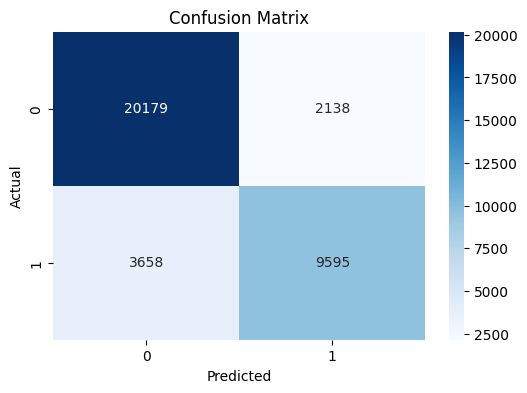

In [ ]:
# Making predictions
y_pred = model.predict(X_test)

# Evaluating model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Justifications:

Model evaluation metrics show how well our model makes predictions on data it hasn’t seen before.
The confusion matrix helps us understand where the model is making correct and incorrect predictions by comparing actual and predicted values. Accuracy tells us the overall percentage of correct predictions made by the model.
Together, these metrics help us judge if the model is reliable and performing as expected.


# 5. Feature Importance (10%)


---

Assess the importance of features within your decision tree model. Provide commentary on the reliability of your model's results based on the feature importance scores.

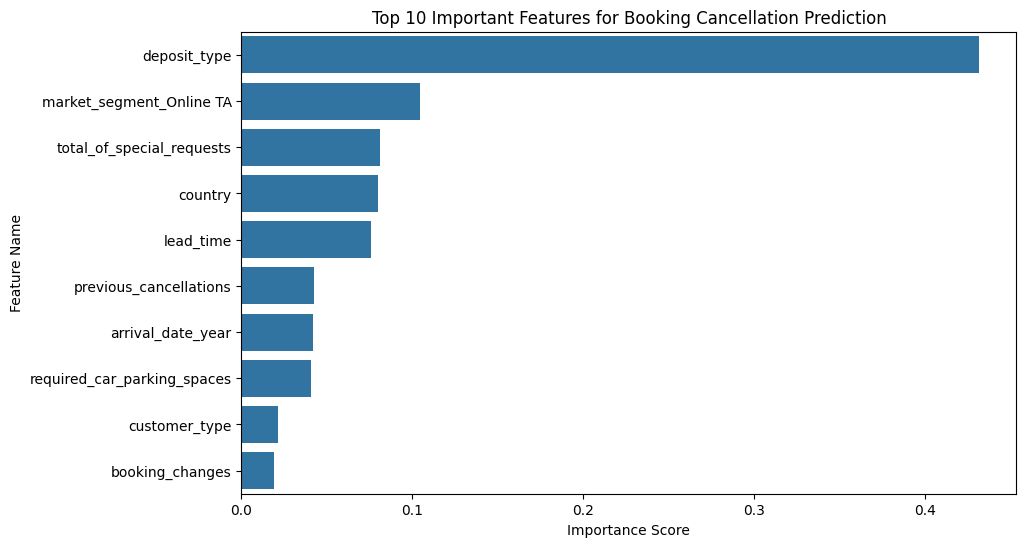

In [ ]:
# Checking feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Display top 10 important features
plt.figure(figsize=(10,6))
sns.barplot(x=importances[:10], y=importances.index[:10])
plt.title("Top 10 Important Features for Booking Cancellation Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.show()


Justifications:

Feature importance helps us see which factors the model relies on the most to make predictions.
It highlights which features, like room type or booking changes, have the biggest impact on cancellations.
By understanding this, we can check if the model is learning meaningful patterns.
It also gives hotel management clear insights into what drives cancellations, helping them make better decisions.

Feature importance shows which variables have the strongest influence on the model’s decisions. Understanding this helps in validating the model and offering actionable insights to hotel management (e.g., factors that most affect cancellations).